This Denmark real-lane notebook mirrors the visible normalization and rolling-view config patterns from the existing `v2` Baltic notebooks, but it runs a single explicit `DK` country section through the typed `macro_indicator_v2` helper path.


In [2]:
from __future__ import annotations

from copy import deepcopy
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "macro_indicator_v2").exists():
        project_root = candidate
        break
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from macro_indicator_v2.infrastructure.notebook import (
    render_real_country_notebook_section,
    resolve_project_root,
)


In [3]:
project_root = resolve_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

project_subdir = project_root / "bs2026_student_projects" / "Arturas_Sotnicenko_v2"
denmark_output_root = project_subdir / "outputs_denmark_v2"
denmark_rolling_output_root = project_subdir / "outputs_denmark_rolling_10y_v2"
country_code = "DK"


## Baseline normalized config

This section mirrors the baseline normalized `v2` notebook shape, but scopes the visible config and outputs to Denmark only.


In [4]:
indicator_groups = {
    "Output and growth": ["real_gdp", "gdp_current_usd", "gdp_per_capita"],
    "Inflation and prices": ["inflation_cpi_yoy"],
    "Fiscal indicators": ["general_government_gross_debt_pct_gdp"],
}
normalized_region_label = "Denmark_v2"
normalization_config = None
force_zscore_refresh = False

# normalization_config = {
#     "mode": "rolling_trailing",
#     "rolling_window_years": 10,
#     "exclude_current_from_window": True,
#     "min_obs_for_zscore": 5,
# }

print(f"Dynamic normalization enabled: {normalization_config is not None}")
print(f"Force refresh: {force_zscore_refresh}")


Dynamic normalization enabled: False
Force refresh: False


In [5]:
def _render_denmark_normalized_section(
    *,
    normalization_config=normalization_config,
    region_label=normalized_region_label,
    force_refresh=force_zscore_refresh,
    show_labels: bool = False,
):
    run = render_real_country_notebook_section(
        country_code=country_code,
        country_output_dir=denmark_output_root / country_code,
        normalization_config=normalization_config,
        region_label=region_label,
        force_refresh=force_refresh,
        indicator_groups=indicator_groups,
        project_root=project_root,
        include_analysis=True,
        reuse_existing=not force_refresh,
        show_sections=True,
        show_manifest=True,
        show_labels=show_labels,
        show_visuals=True,
    )
    return run.notebook_view


In [5]:
_dk_baseline_view = _render_denmark_normalized_section()


### Denmark

- Render: Denmark | baseline static | region Denmark_v2

- Normalization: Static baseline from 1999, min obs 3

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,DK,Denmark,baseline_static,Denmark_v2,"Static baseline from 1999, min obs 3",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Fiscal indicators,general_government_gross_debt_pct_gdp
1,Inflation and prices,inflation_cpi_yoy
2,Output and growth,"real_gdp, gdp_current_usd, gdp_per_capita"
3,Remaining,"exchange_rate_lcu_per_usd, general_government_..."


#### Chart artifacts

_Missing zscore_heatmap: /workspaces/da-ai-v2/bs2026_student_projects/Arturas_Sotnicenko_v2/outputs_denmark_v2/DK/charts/zscore_normalization_heatmap.png_

_Missing zscore_timelines: /workspaces/da-ai-v2/bs2026_student_projects/Arturas_Sotnicenko_v2/outputs_denmark_v2/DK/charts/zscore_normalization_timelines.png_

## Inflation rolling override example

This keeps the same visible inflation-specific override pattern as the normalized Baltic notebook while rendering the Denmark section through the typed helper.


### Denmark

- Render: Denmark | dynamic notebook | region Denmark_v2_inflation_override

- Normalization: Static baseline from 1800, min obs 3 | 1 indicator override

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,DK,Denmark,dynamic_notebook,Denmark_v2_inflation_override,"Static baseline from 1800, min obs 3 | 1 indic...",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


...

#### Render manifest

,chart_type,status,file_path,render_origin,region_label,normalization_mode,config_slug,transformation_strategy_slug
0,zscore_heatmap,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Denmark_v2_inflation_override,static_baseline,mode_static_baseline__baseline_1800__limit_1__...,
1,zscore_timelines,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Denmark_v2_inflation_override,static_baseline,mode_static_baseline__baseline_1800__limit_1__...,


#### Chart labels

,indicator_id,indicator_label,source_label,indicator_source_label
0,exchange_rate_lcu_per_usd,Exchange rate,World Bank,Exchange rate | World Bank
1,gdp_current_usd,Nominal GDP,World Bank,Nominal GDP | World Bank
2,gdp_per_capita,GDP per capita,World Bank,GDP per capita | World Bank
3,general_government_balance_deficit_pct_gdp,General government balance/deficit,Eurostat,General government balance/deficit | Eurostat
4,general_government_gross_debt_pct_gdp,General government gross debt,IMF,General government gross debt | IMF
5,inflation_cpi_yoy,Inflation,World Bank,Inflation | World Bank
6,lending_interest_rate,Interest rate,Eurostat,Interest rate | Eurostat
7,real_gdp,Real GDP,World Bank,Real GDP | World Bank
8,trade_balance_pct_gdp,Trade balance,World Bank,Trade balance | World Bank
9,unemployment_rate,Unemployment rate,World Bank,Unemployment rate | World Bank


#### Chart artifacts

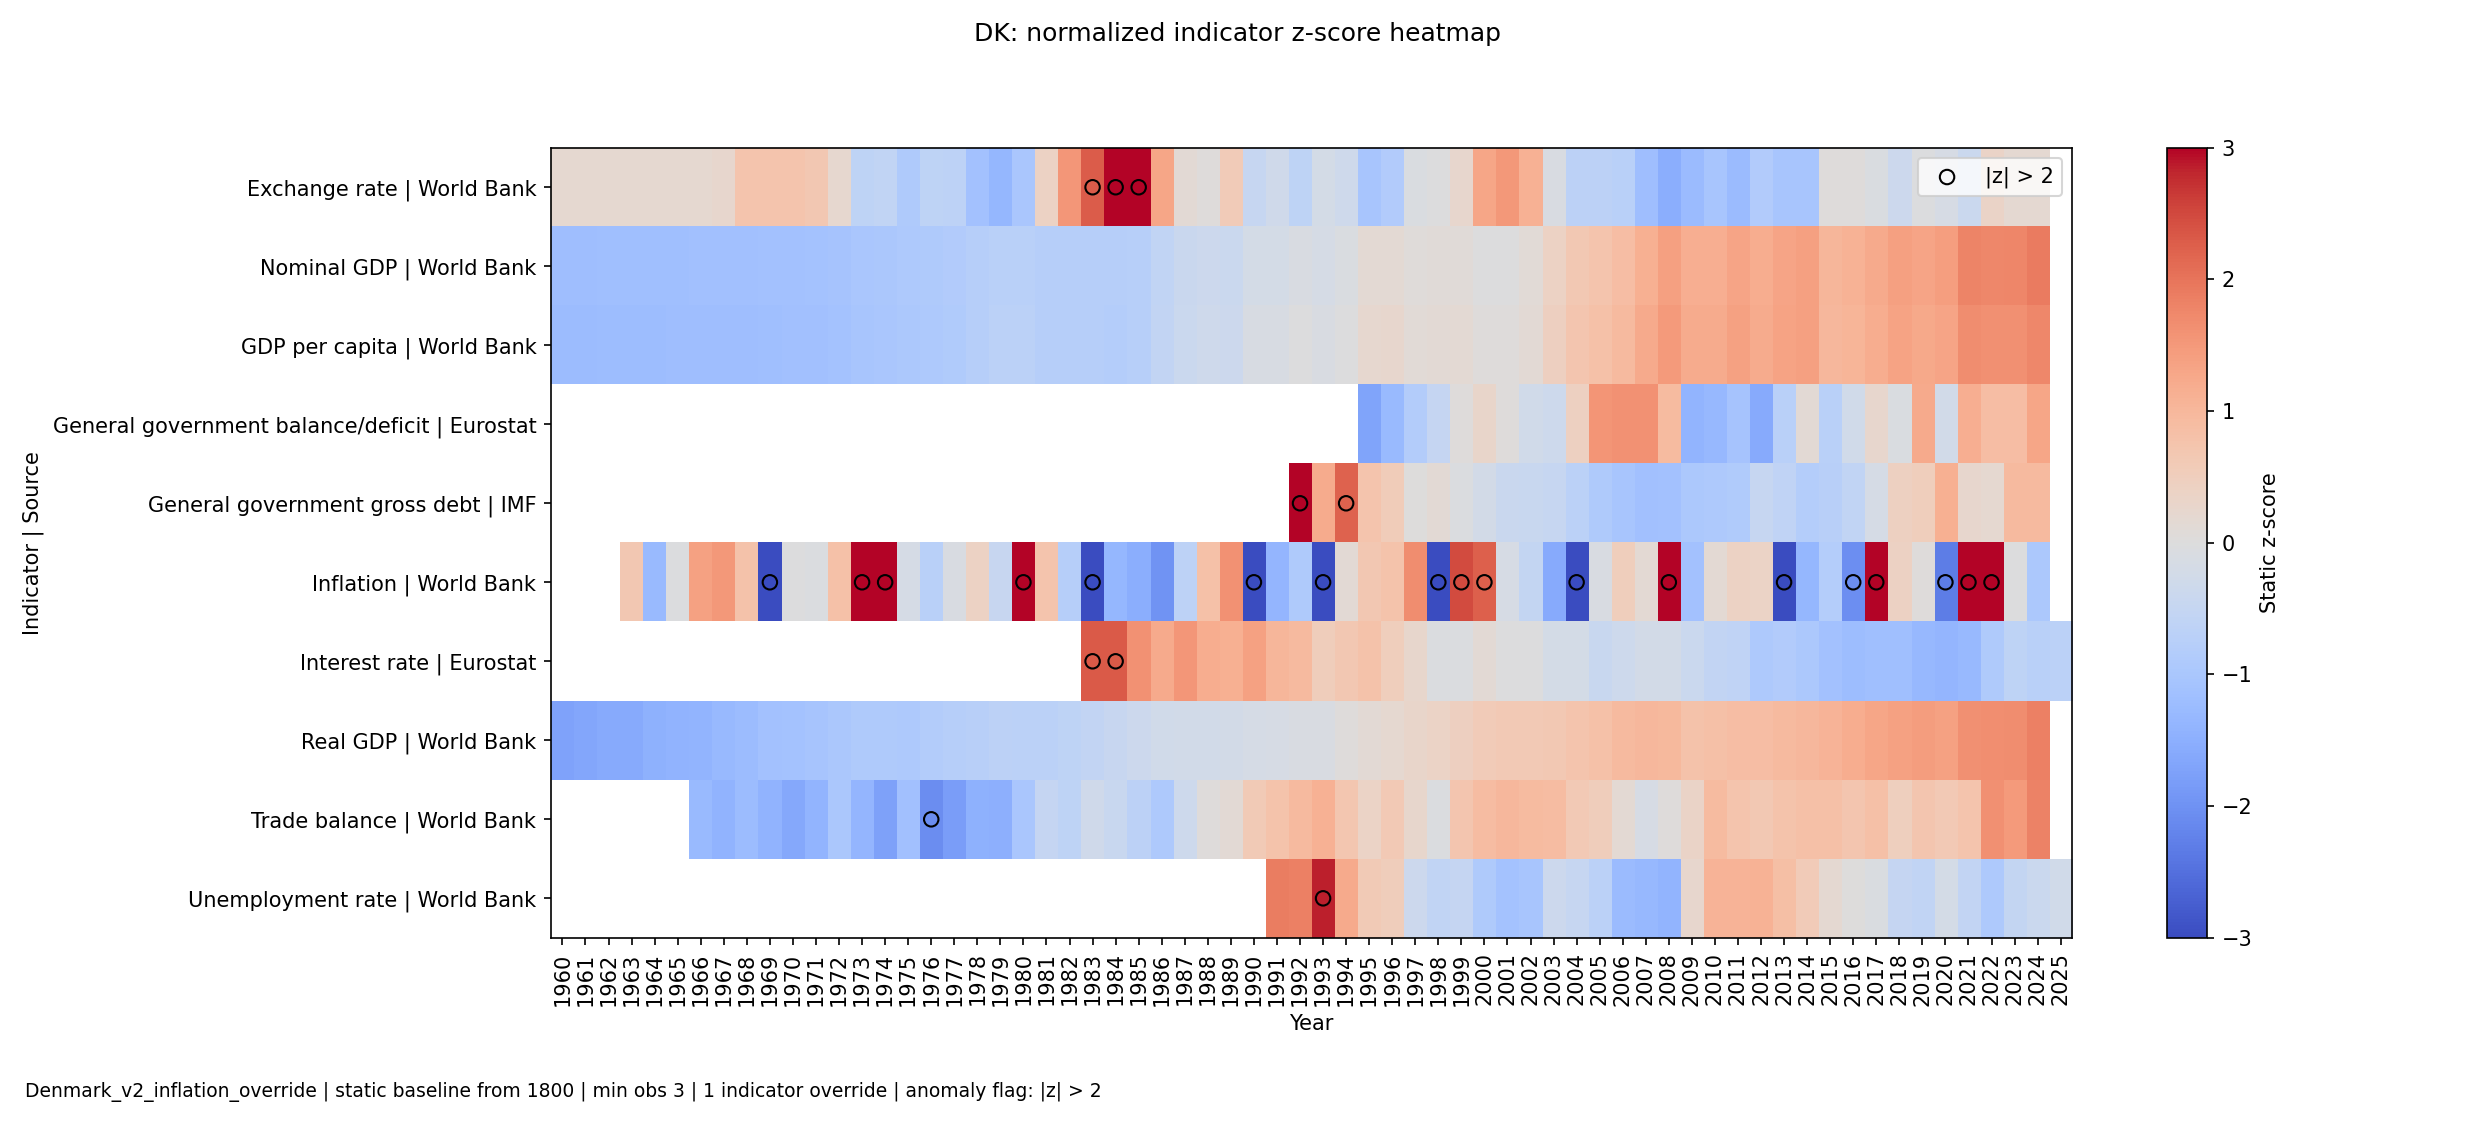

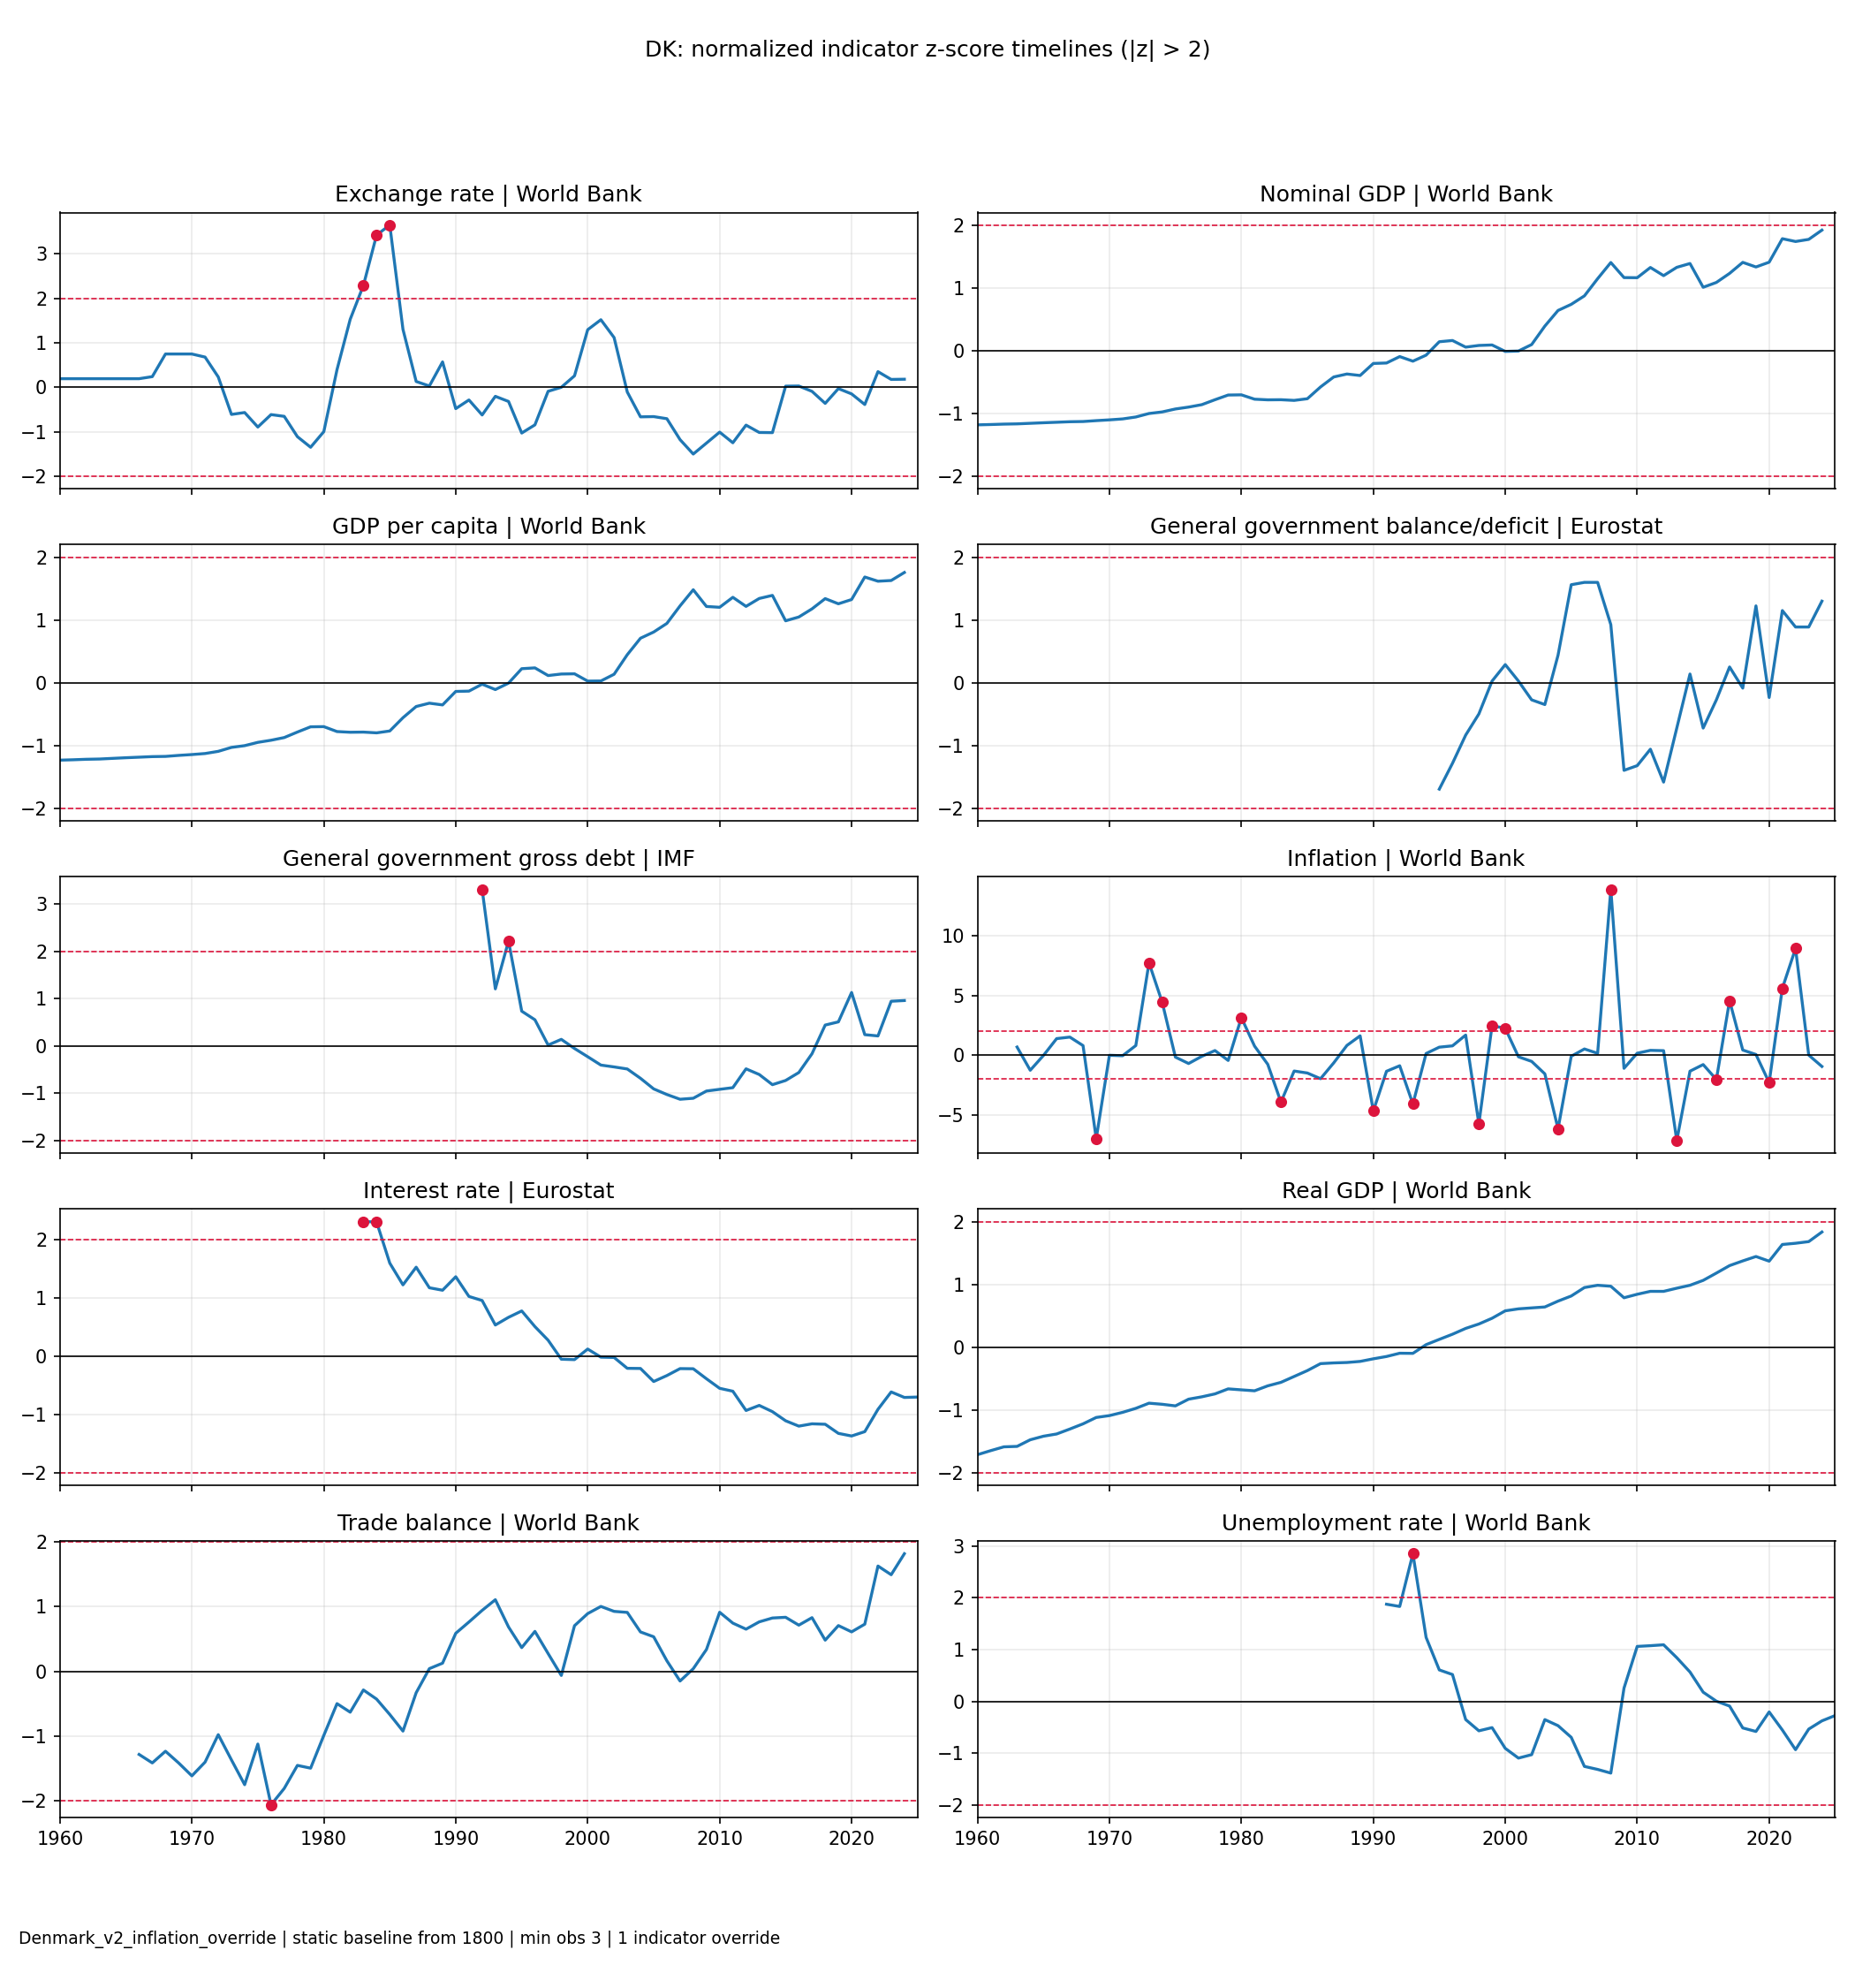

In [8]:
inflation_rolling_override_config = {
    "mode": "static_baseline",
    "baseline_start_year": 1800,
    "limit_to_baseline_window": True,
    "min_obs_for_zscore": 3,
    "indicator_overrides": {
        "inflation_cpi_yoy": {
            "mode": "rolling_trailing",
            "rolling_window_years": 3,
            "exclude_current_from_window": True,
            "min_obs_for_zscore": 3,
        }
    },
}

_dk_inflation_override_view = _render_denmark_normalized_section(
    normalization_config=inflation_rolling_override_config,
    region_label=f"{normalized_region_label}_inflation_override",
    force_refresh=True,
    show_labels=True,
)


## Rolling notebook view config contract

This section mirrors the rolling `v2` notebook's presentation-versus-methodology pattern, but targets a single Denmark output root.


In [6]:
def _build_recommended_gdp_growth_transformation_strategy(*, include_nominal_gdp: bool = False):
    strategy = {
        "harmonization": {"mode": "built_in"},
        "analytical": {
            "method": "none",
            "keep_original": True,
            "indicator_overrides": {
                "gdp_per_capita": {
                    "method": "log_diff_yoy",
                    "emit_indicator_id": "gdp_per_capita_yoy_log_pct",
                    "indicator_name": "GDP per capita growth",
                    "specificity": "Annual log growth, %",
                    "unit": "percent",
                    "keep_original": True,
                },
                "real_gdp": {
                    "method": "log_diff_yoy",
                    "emit_indicator_id": "real_gdp_yoy_log_pct",
                    "indicator_name": "Real GDP growth",
                    "specificity": "Annual log growth, %",
                    "unit": "percent",
                    "keep_original": True,
                },
            },
        },
    }
    if include_nominal_gdp:
        strategy["analytical"]["indicator_overrides"] = deepcopy(
            strategy["analytical"]["indicator_overrides"]
        )
        strategy["analytical"]["indicator_overrides"]["gdp_current_usd"] = {
            "method": "log_diff_yoy",
            "emit_indicator_id": "gdp_current_usd_yoy_log_pct",
            "indicator_name": "Nominal GDP growth",
            "specificity": "Annual log growth, %",
            "unit": "percent",
            "keep_original": True,
        }
    return strategy


rolling_normalization_config = {
    "mode": "rolling_trailing",
    "rolling_window_years": 10,
    "exclude_current_from_window": True,
    "min_obs_for_zscore": 5,
}

presentation_view_config = {
    "view_name": "presentation_view",
    "normalization_config": deepcopy(rolling_normalization_config),
    "transformation_strategy": _build_recommended_gdp_growth_transformation_strategy(),
    "region_label": "Denmark presentation",
    "force_refresh": True,
    "indicator_groups": {
        "Growth narrative": [
            "real_gdp_yoy_log_pct",
            "gdp_per_capita_yoy_log_pct",
            "inflation_cpi_yoy",
        ],
        "Context": ["general_government_gross_debt_pct_gdp"],
    },
    "show_sections": True,
    "show_manifest": False,
    "show_labels": False,
}
methodology_view_config = {
    "view_name": "methodology_view",
    "normalization_config": deepcopy(rolling_normalization_config),
    "transformation_strategy": None,
    "region_label": "Denmark methodology",
    "force_refresh": True,
    "indicator_groups": {
        "Output and growth": ["real_gdp", "gdp_per_capita", "gdp_current_usd"],
        "Inflation and prices": ["inflation_cpi_yoy"],
        "Fiscal indicators": ["general_government_gross_debt_pct_gdp"],
    },
    "show_sections": True,
    "show_manifest": True,
    "show_labels": True,
}
notebook_view_configs = {
    "presentation": presentation_view_config,
    "methodology": methodology_view_config,
}

active_notebook_view_name = "methodology"
active_notebook_view_config = notebook_view_configs[active_notebook_view_name]
_USE_CURRENT_NOTEBOOK_DEFAULT = object()

normalization_config = active_notebook_view_config["normalization_config"]
transformation_strategy = active_notebook_view_config["transformation_strategy"]
normalized_region_label = active_notebook_view_config["region_label"]
force_zscore_refresh = active_notebook_view_config["force_refresh"]
indicator_groups = active_notebook_view_config["indicator_groups"]

print(f"Active notebook view: {active_notebook_view_name}")
print(f"Active normalization enabled: {normalization_config is not None}")
print(f"Active transformation enabled: {transformation_strategy is not None}")


Active notebook view: methodology
Active normalization enabled: True
Active transformation enabled: False


In [7]:
def _render_denmark_rolling_section(
    *,
    view_name: str,
    view_config: dict[str, object] | None = None,
    normalization_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    transformation_strategy=_USE_CURRENT_NOTEBOOK_DEFAULT,
    region_label=_USE_CURRENT_NOTEBOOK_DEFAULT,
    force_refresh=_USE_CURRENT_NOTEBOOK_DEFAULT,
    indicator_groups=_USE_CURRENT_NOTEBOOK_DEFAULT,
):
    effective_view_config = active_notebook_view_config if view_config is None else view_config
    effective_normalization_config = (
        effective_view_config["normalization_config"]
        if normalization_config is _USE_CURRENT_NOTEBOOK_DEFAULT
        else normalization_config
    )
    effective_transformation_strategy = (
        effective_view_config["transformation_strategy"]
        if transformation_strategy is _USE_CURRENT_NOTEBOOK_DEFAULT
        else transformation_strategy
    )
    effective_region_label = (
        effective_view_config["region_label"]
        if region_label is _USE_CURRENT_NOTEBOOK_DEFAULT
        else region_label
    )
    effective_force_refresh = (
        effective_view_config["force_refresh"]
        if force_refresh is _USE_CURRENT_NOTEBOOK_DEFAULT
        else force_refresh
    )
    effective_indicator_groups = (
        effective_view_config["indicator_groups"]
        if indicator_groups is _USE_CURRENT_NOTEBOOK_DEFAULT
        else indicator_groups
    )

    run = render_real_country_notebook_section(
        country_code=country_code,
        country_output_dir=denmark_rolling_output_root / country_code / view_name,
        normalization_config=effective_normalization_config,
        transformation_strategy=effective_transformation_strategy,
        region_label=effective_region_label,
        force_refresh=effective_force_refresh,
        indicator_groups=effective_indicator_groups,
        project_root=project_root,
        include_analysis=True,
        reuse_existing=not effective_force_refresh,
        show_sections=bool(effective_view_config.get("show_sections", True)),
        show_manifest=bool(effective_view_config.get("show_manifest", True)),
        show_labels=bool(effective_view_config.get("show_labels", False)),
        show_visuals=True,
    )
    return run.notebook_view


## Presentation view

The presentation view keeps the rolling normalization plus GDP-growth transformation visible in notebook config, then renders the transformed Denmark `v2` view.


### Denmark

- Render: Denmark | dynamic notebook | region Denmark presentation

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,DK,Denmark,dynamic_notebook,Denmark presentation,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: GDP per capita growth, ...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

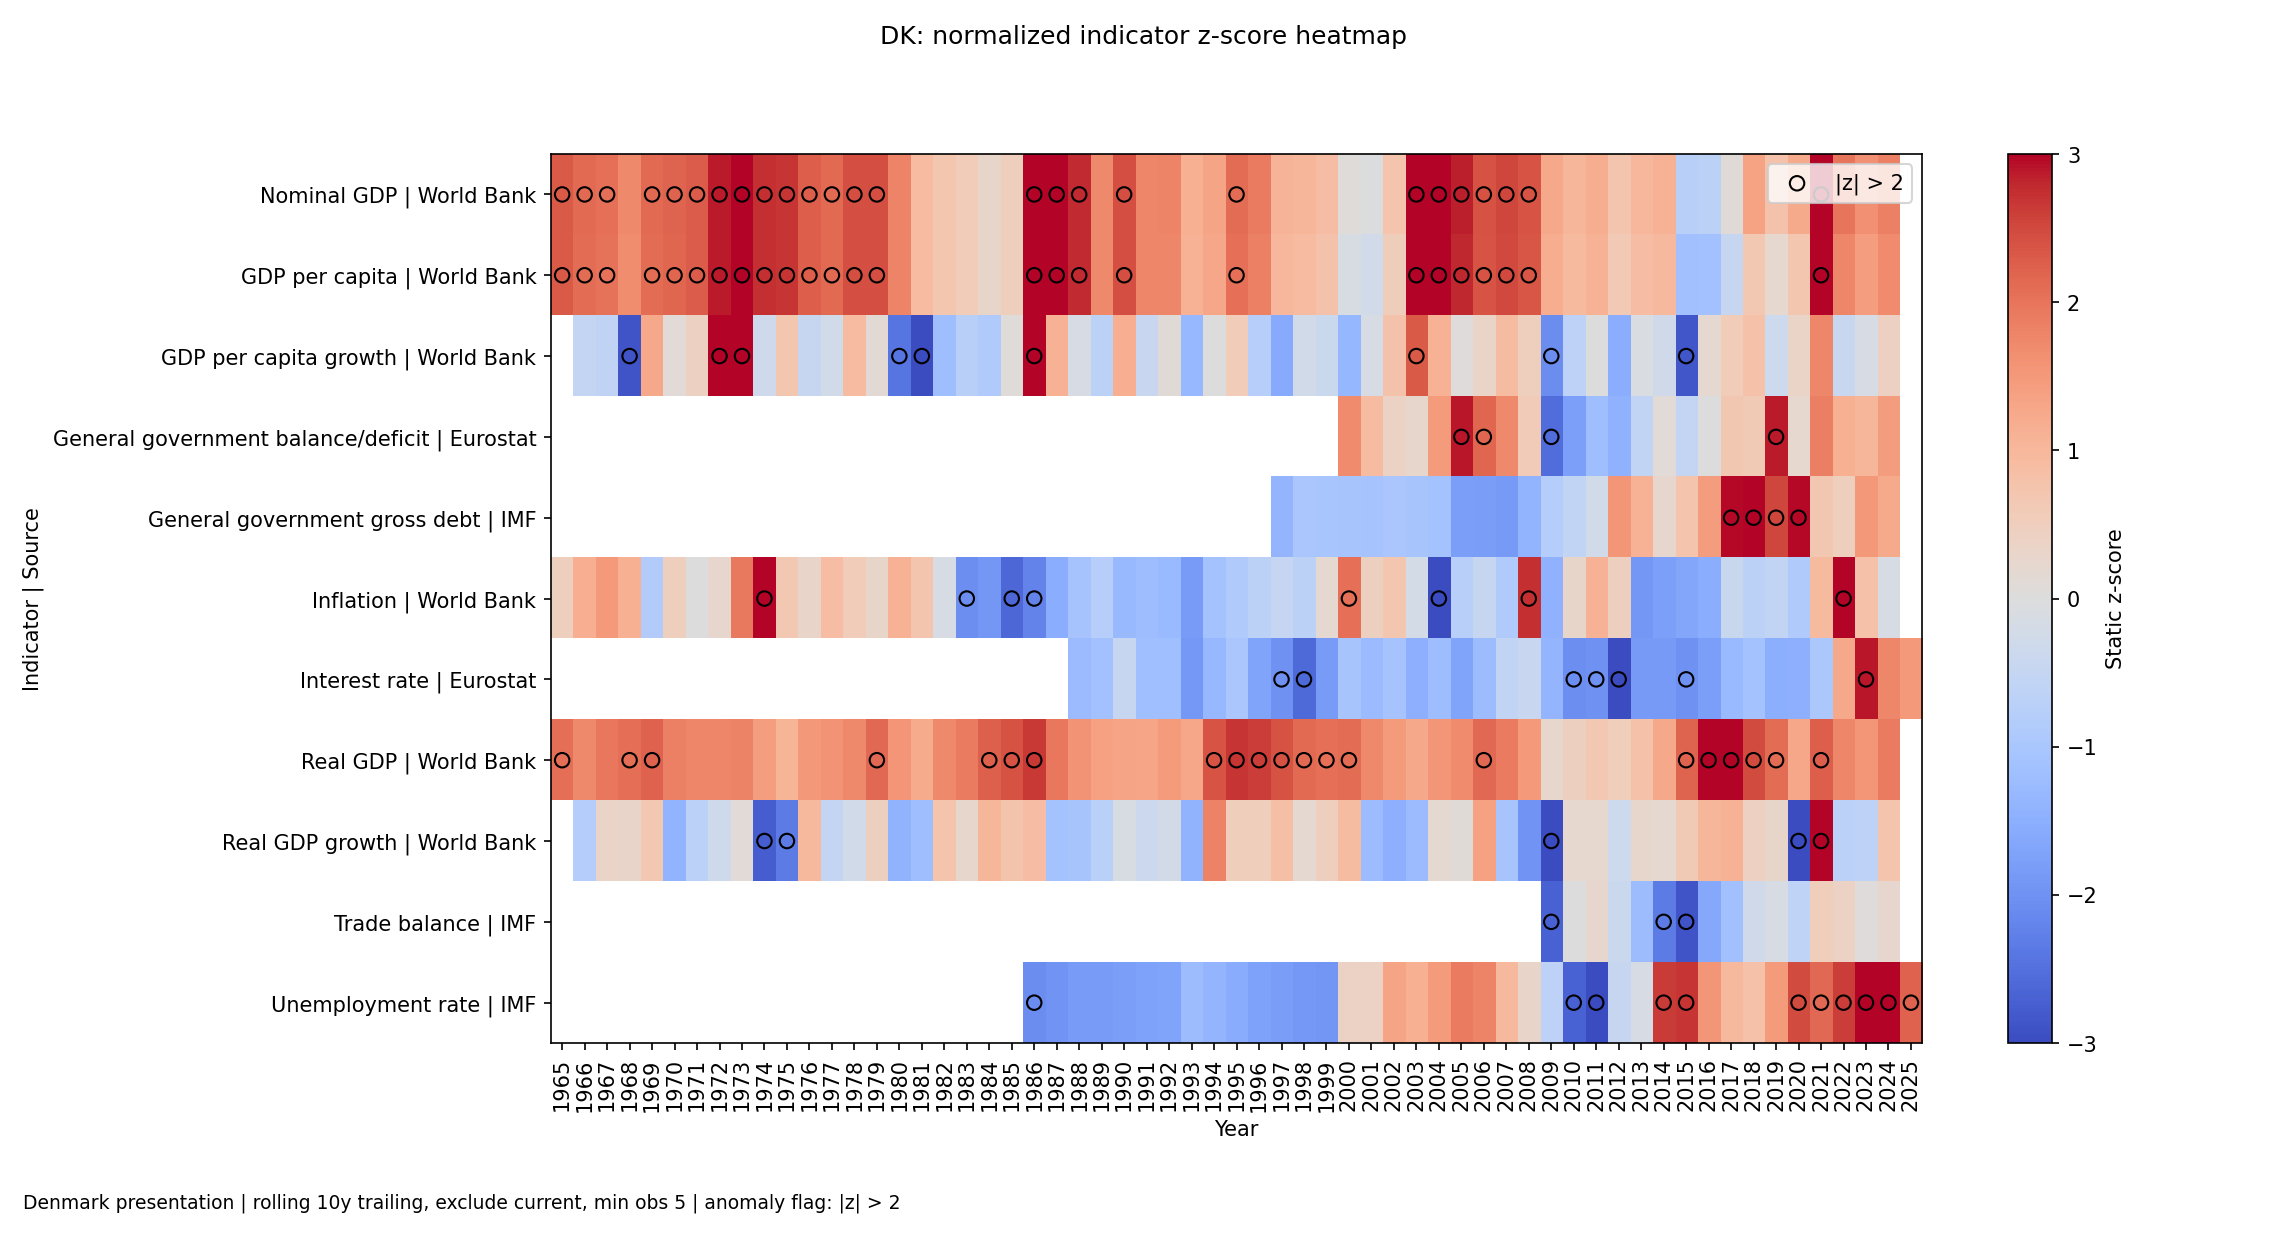

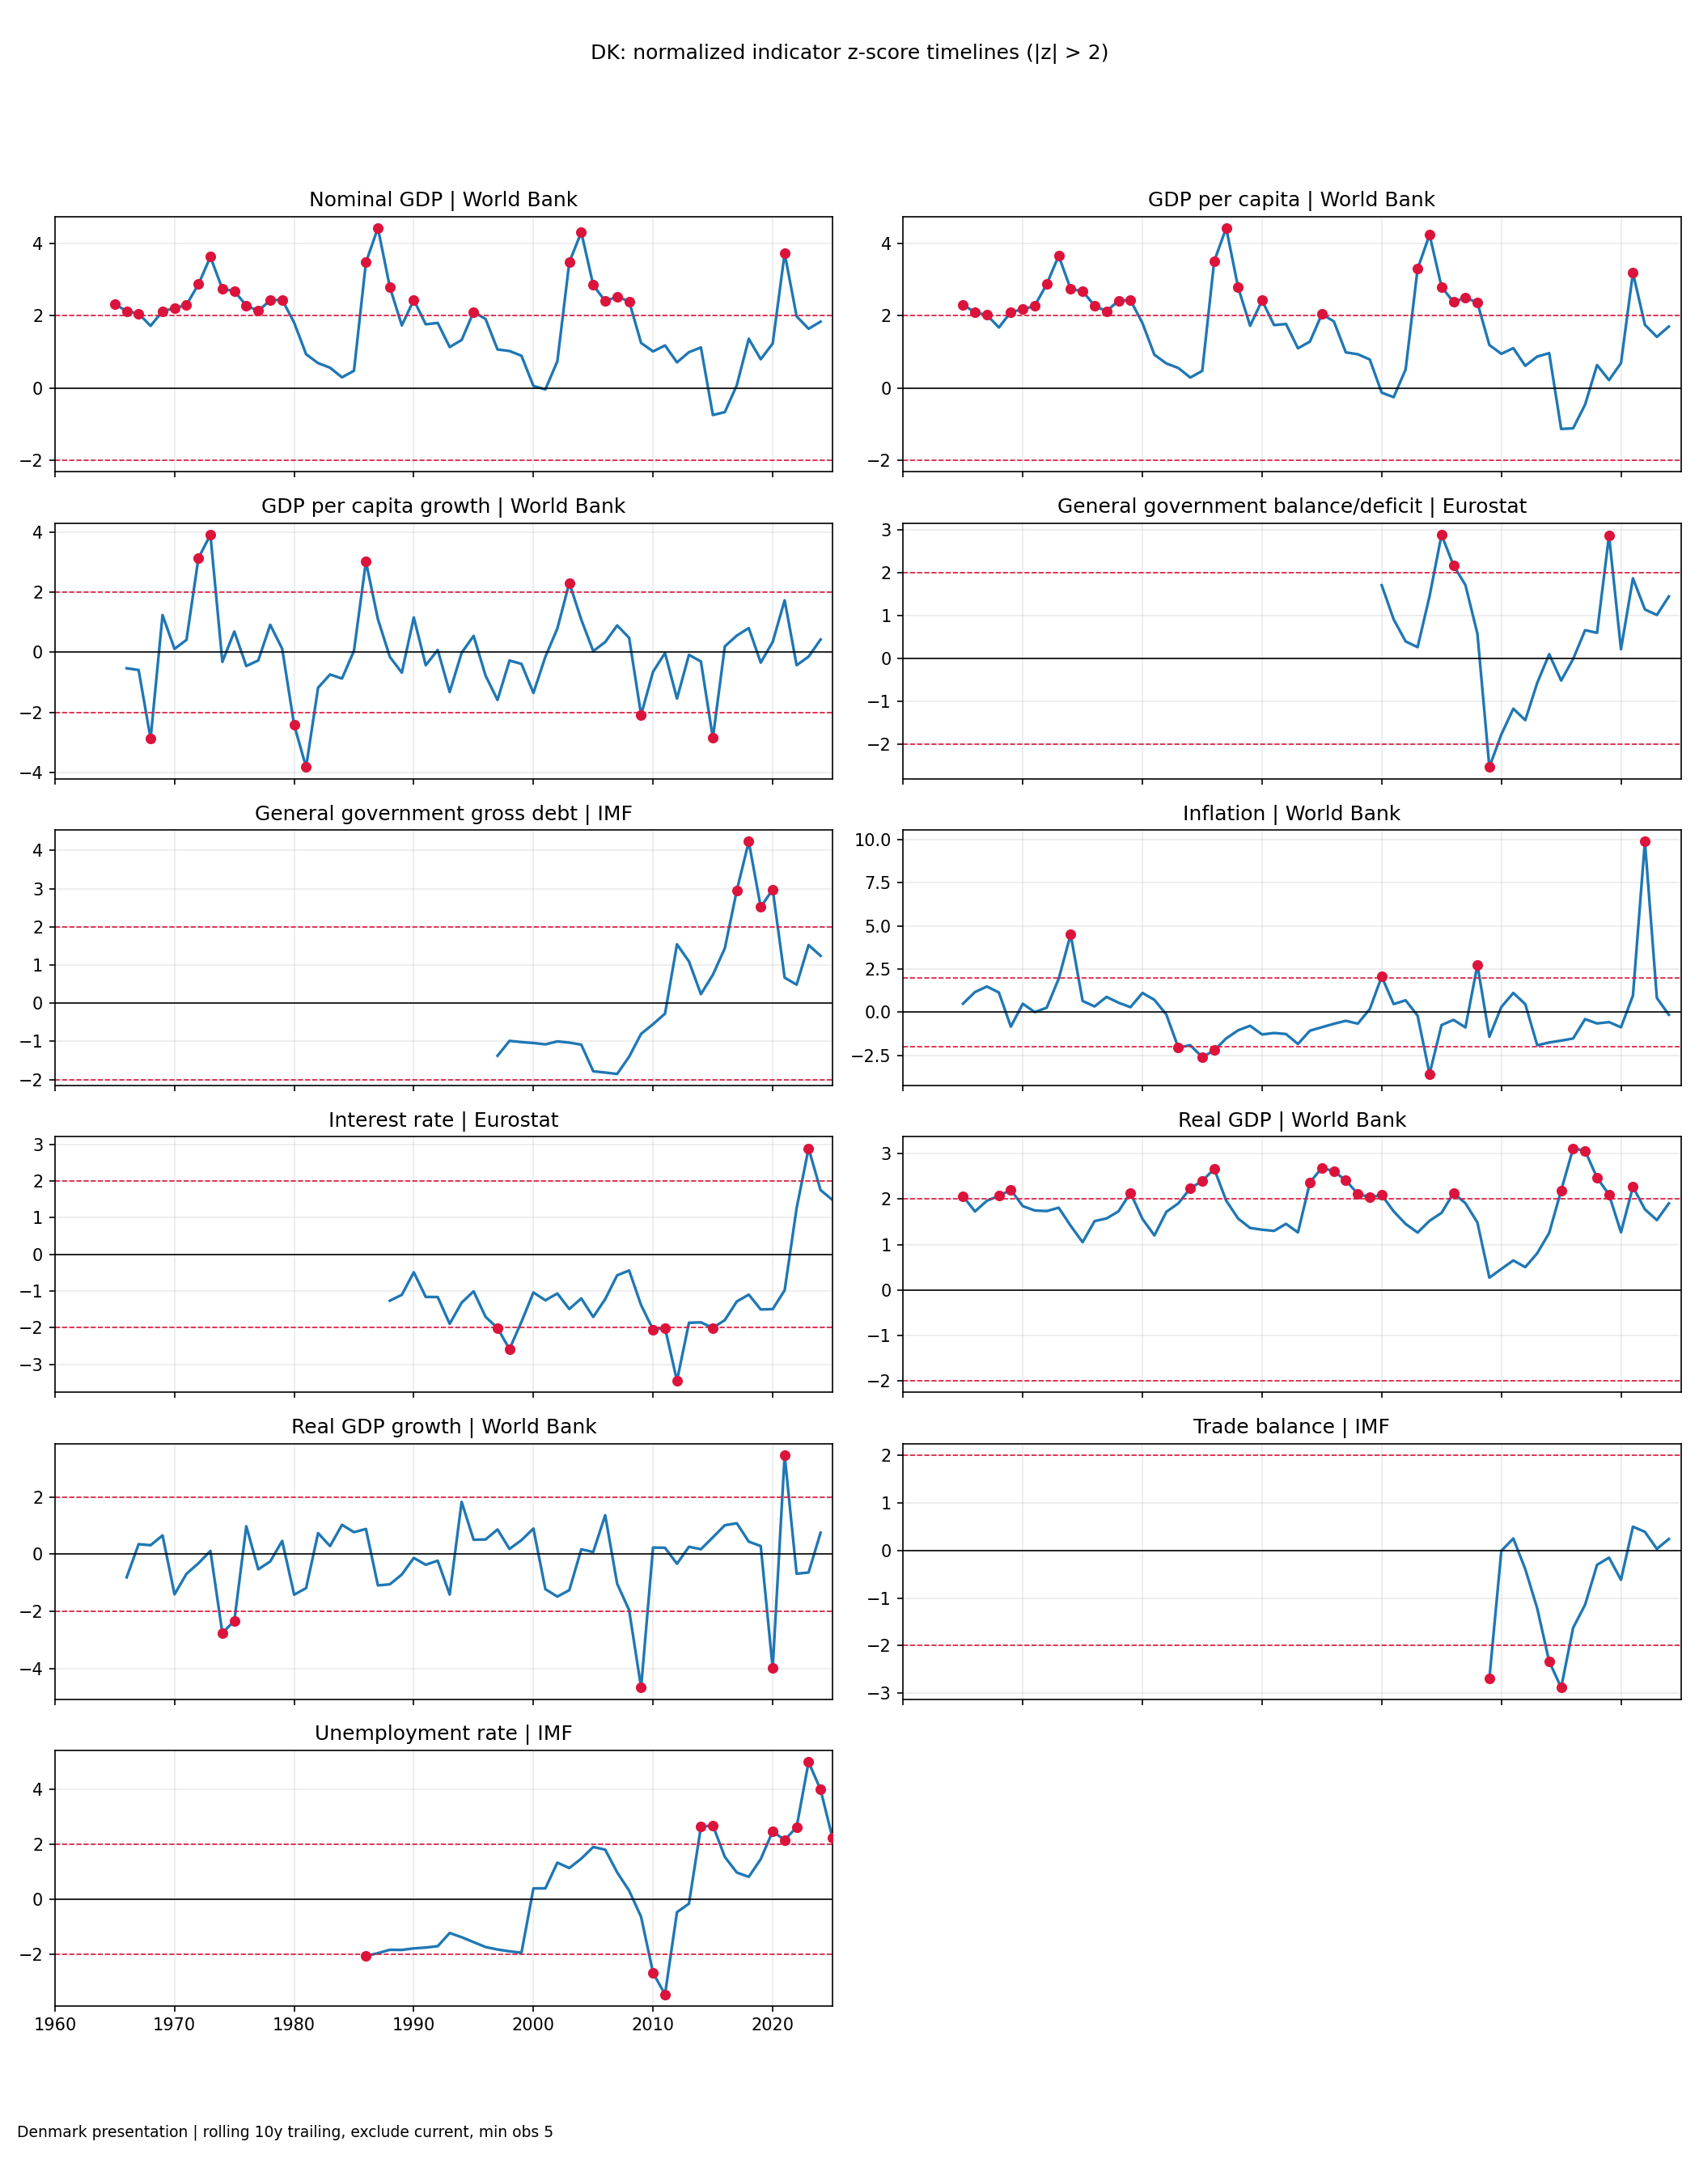

In [8]:
_dk_presentation_view = _render_denmark_rolling_section(
    view_name=presentation_view_config["view_name"],
    view_config=presentation_view_config,
)


## Methodology view

The methodology view keeps the same rolling normalization but turns on the richer typed notebook metadata so the rendered Denmark view exposes manifest, label, and section context beside the visuals.


### Denmark

- Render: Denmark | dynamic notebook | region Denmark methodology

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,DK,Denmark,dynamic_notebook,Denmark methodology,"Rolling trailing, 10y, exclude current, min obs 5",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


...

#### Render manifest

,chart_type,status,file_path,render_origin,region_label,normalization_mode,config_slug,transformation_strategy_slug
0,zscore_heatmap,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Denmark methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,
1,zscore_timelines,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Denmark methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,


#### Chart labels

,indicator_id,indicator_label,source_label,indicator_source_label
0,exchange_rate_lcu_per_usd,Exchange rate,World Bank,Exchange rate | World Bank
1,gdp_current_usd,Nominal GDP,World Bank,Nominal GDP | World Bank
2,gdp_per_capita,GDP per capita,World Bank,GDP per capita | World Bank
3,general_government_balance_deficit_pct_gdp,General government balance/deficit,Eurostat,General government balance/deficit | Eurostat
4,general_government_gross_debt_pct_gdp,General government gross debt,IMF,General government gross debt | IMF
5,inflation_cpi_yoy,Inflation,World Bank,Inflation | World Bank
6,lending_interest_rate,Interest rate,Eurostat,Interest rate | Eurostat
7,real_gdp,Real GDP,World Bank,Real GDP | World Bank
8,trade_balance_pct_gdp,Trade balance,World Bank,Trade balance | World Bank
9,unemployment_rate,Unemployment rate,World Bank,Unemployment rate | World Bank


#### Chart artifacts

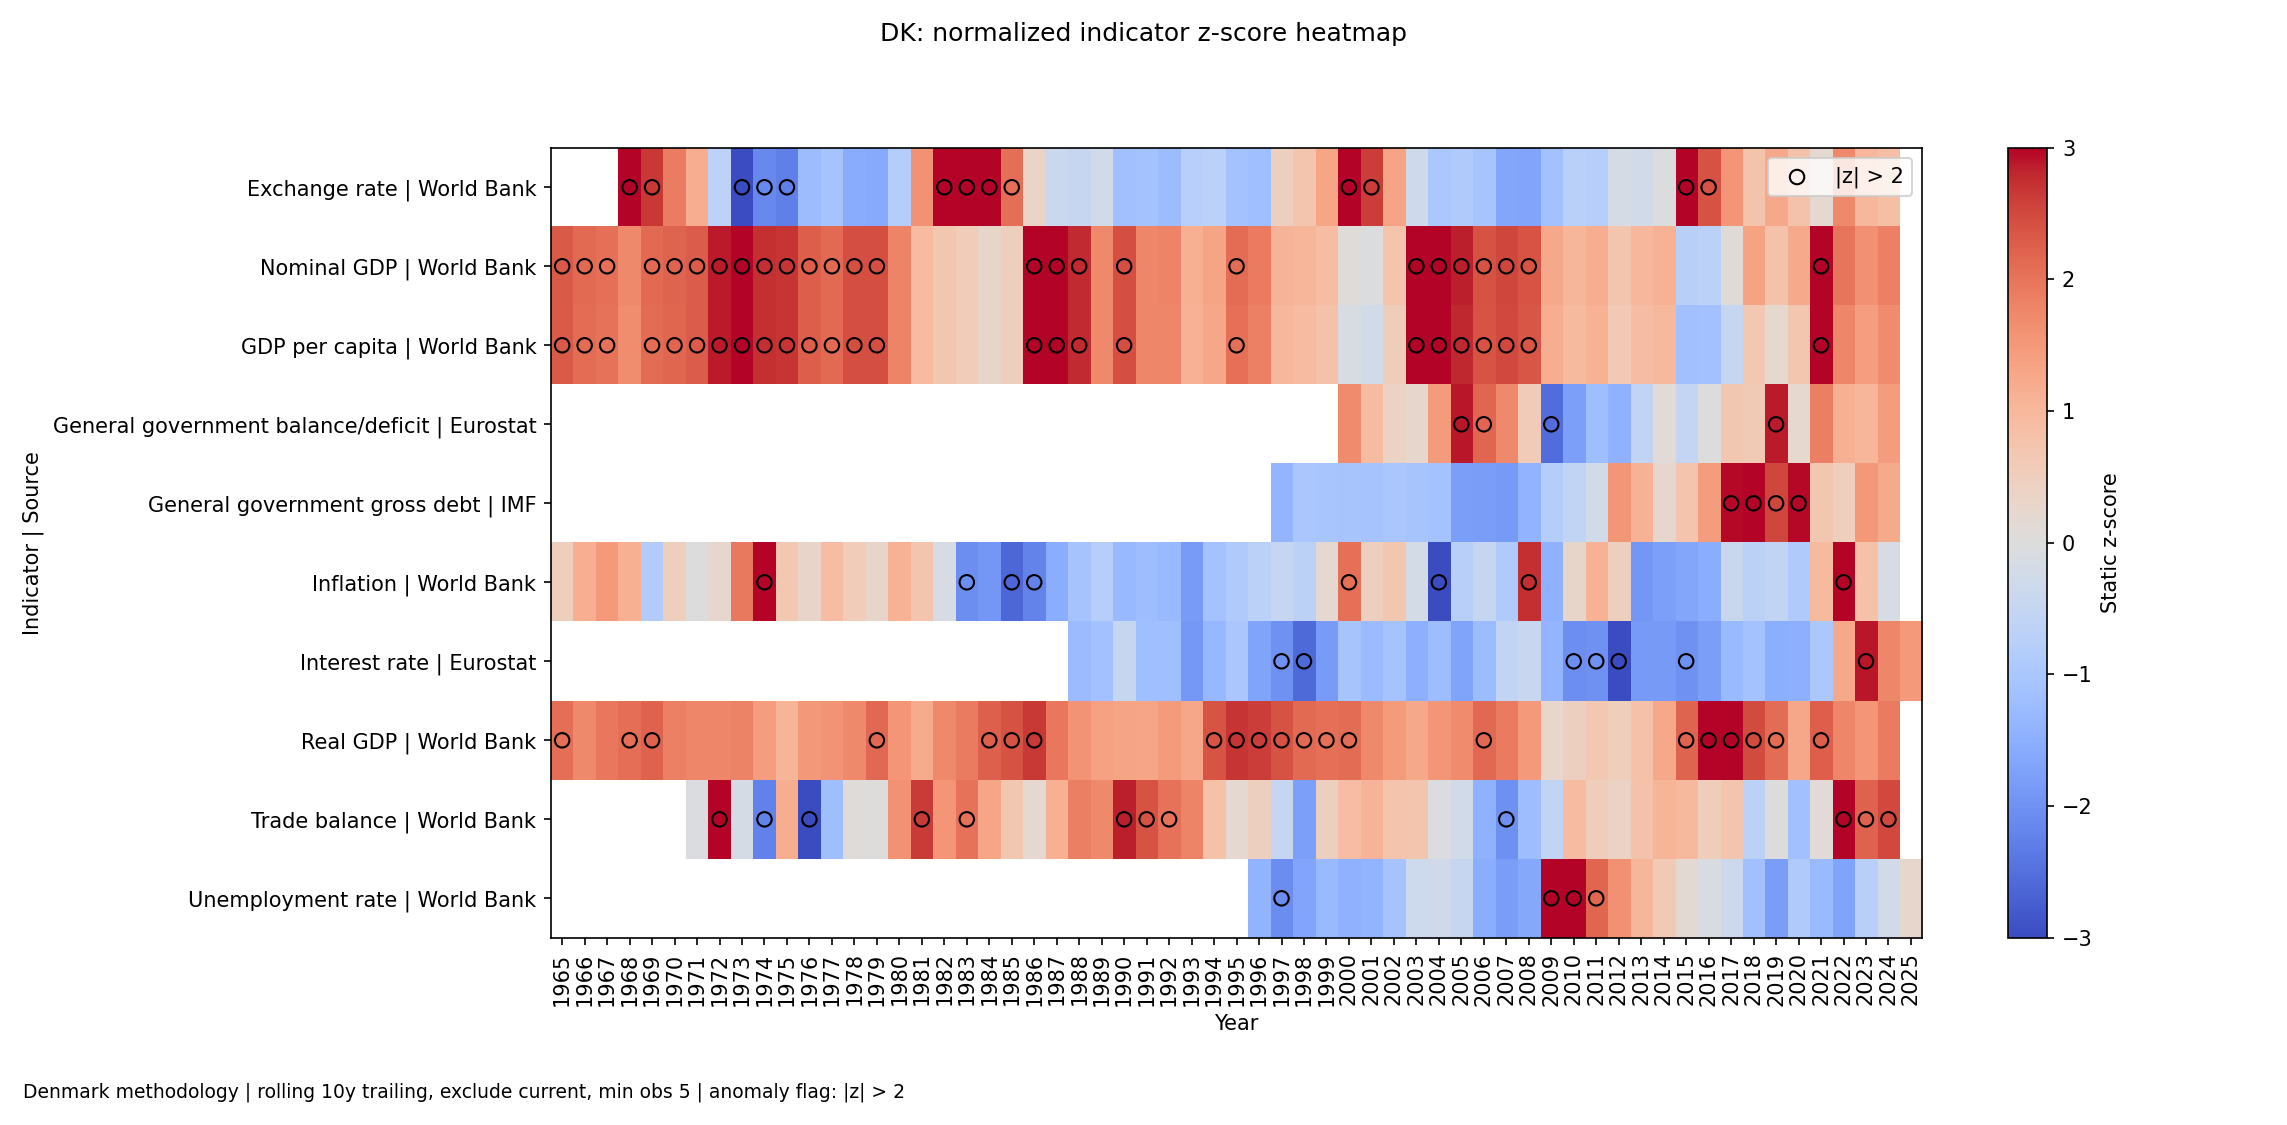

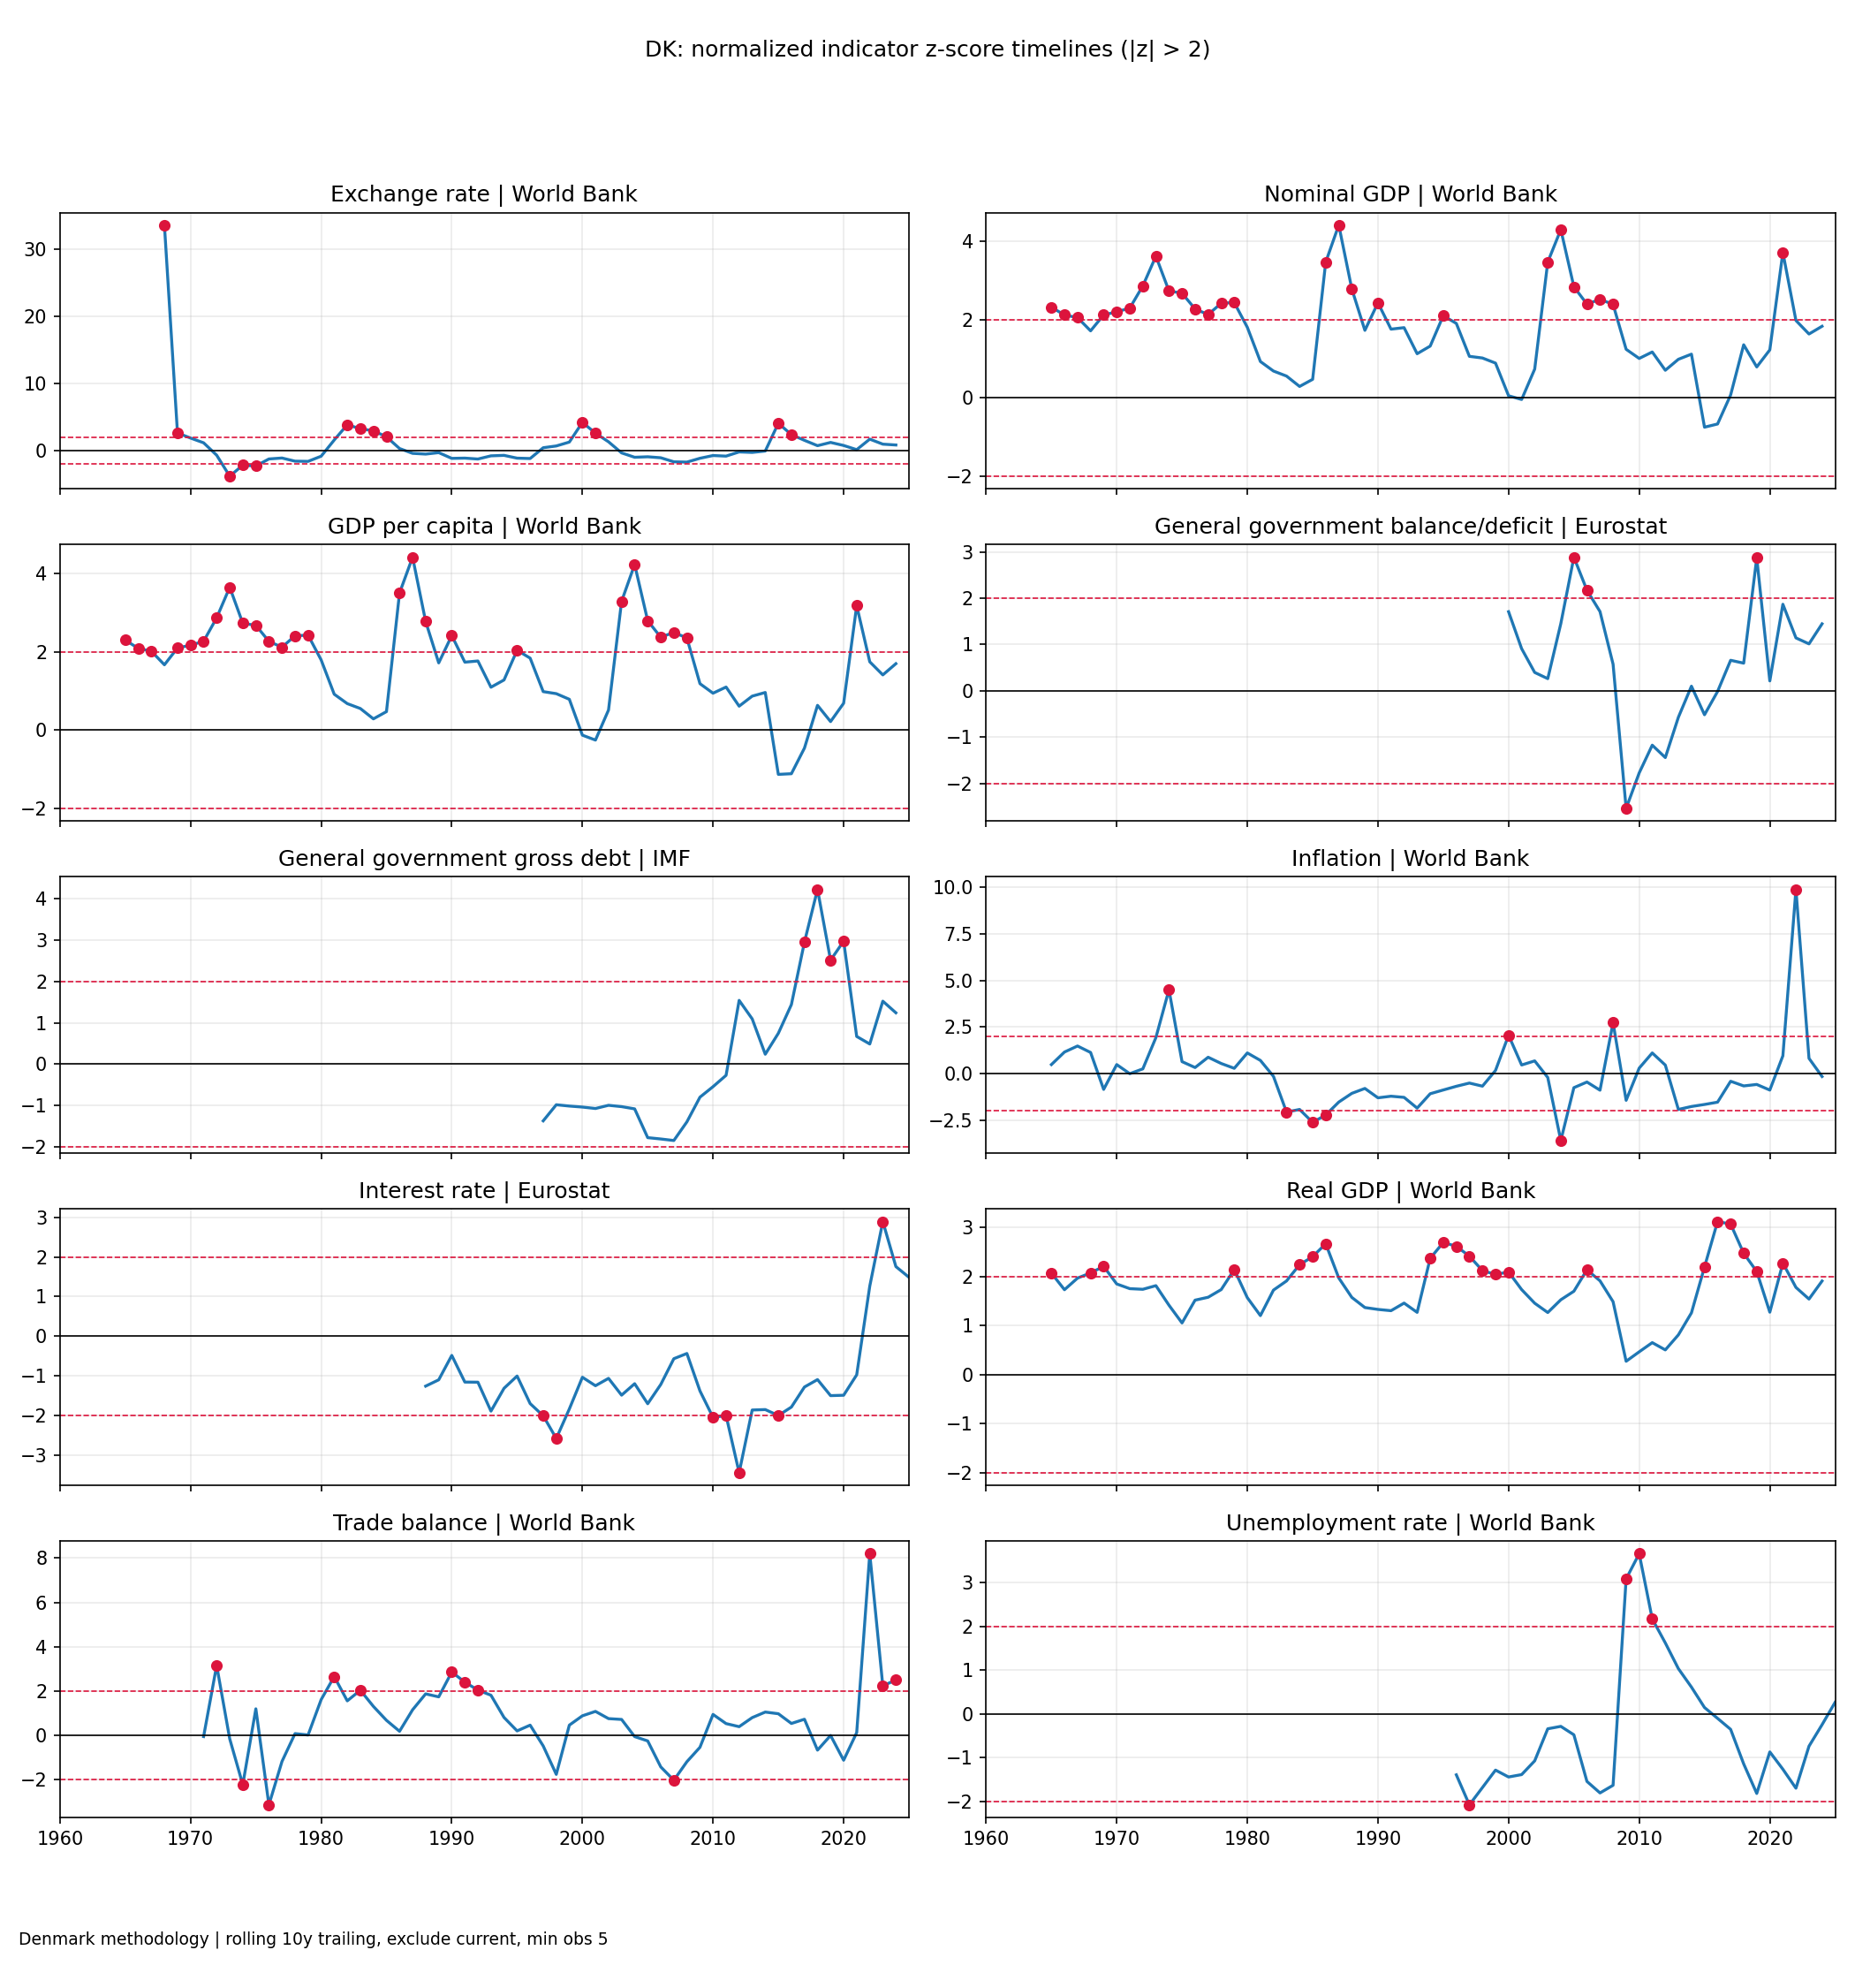

In [9]:
_dk_methodology_view = _render_denmark_rolling_section(
    view_name=methodology_view_config["view_name"],
    view_config=methodology_view_config,
)


## Optional nominal GDP growth variant

Set `include_nominal_gdp=True` when you want to inspect the additive nominal-growth transform without changing the default presentation or methodology configs.


### Denmark

- Render: Denmark | dynamic notebook | region Denmark_nominal

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: Nominal GDP growth, GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,DK,Denmark,dynamic_notebook,Denmark_nominal,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: Nominal GDP growth, GDP...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

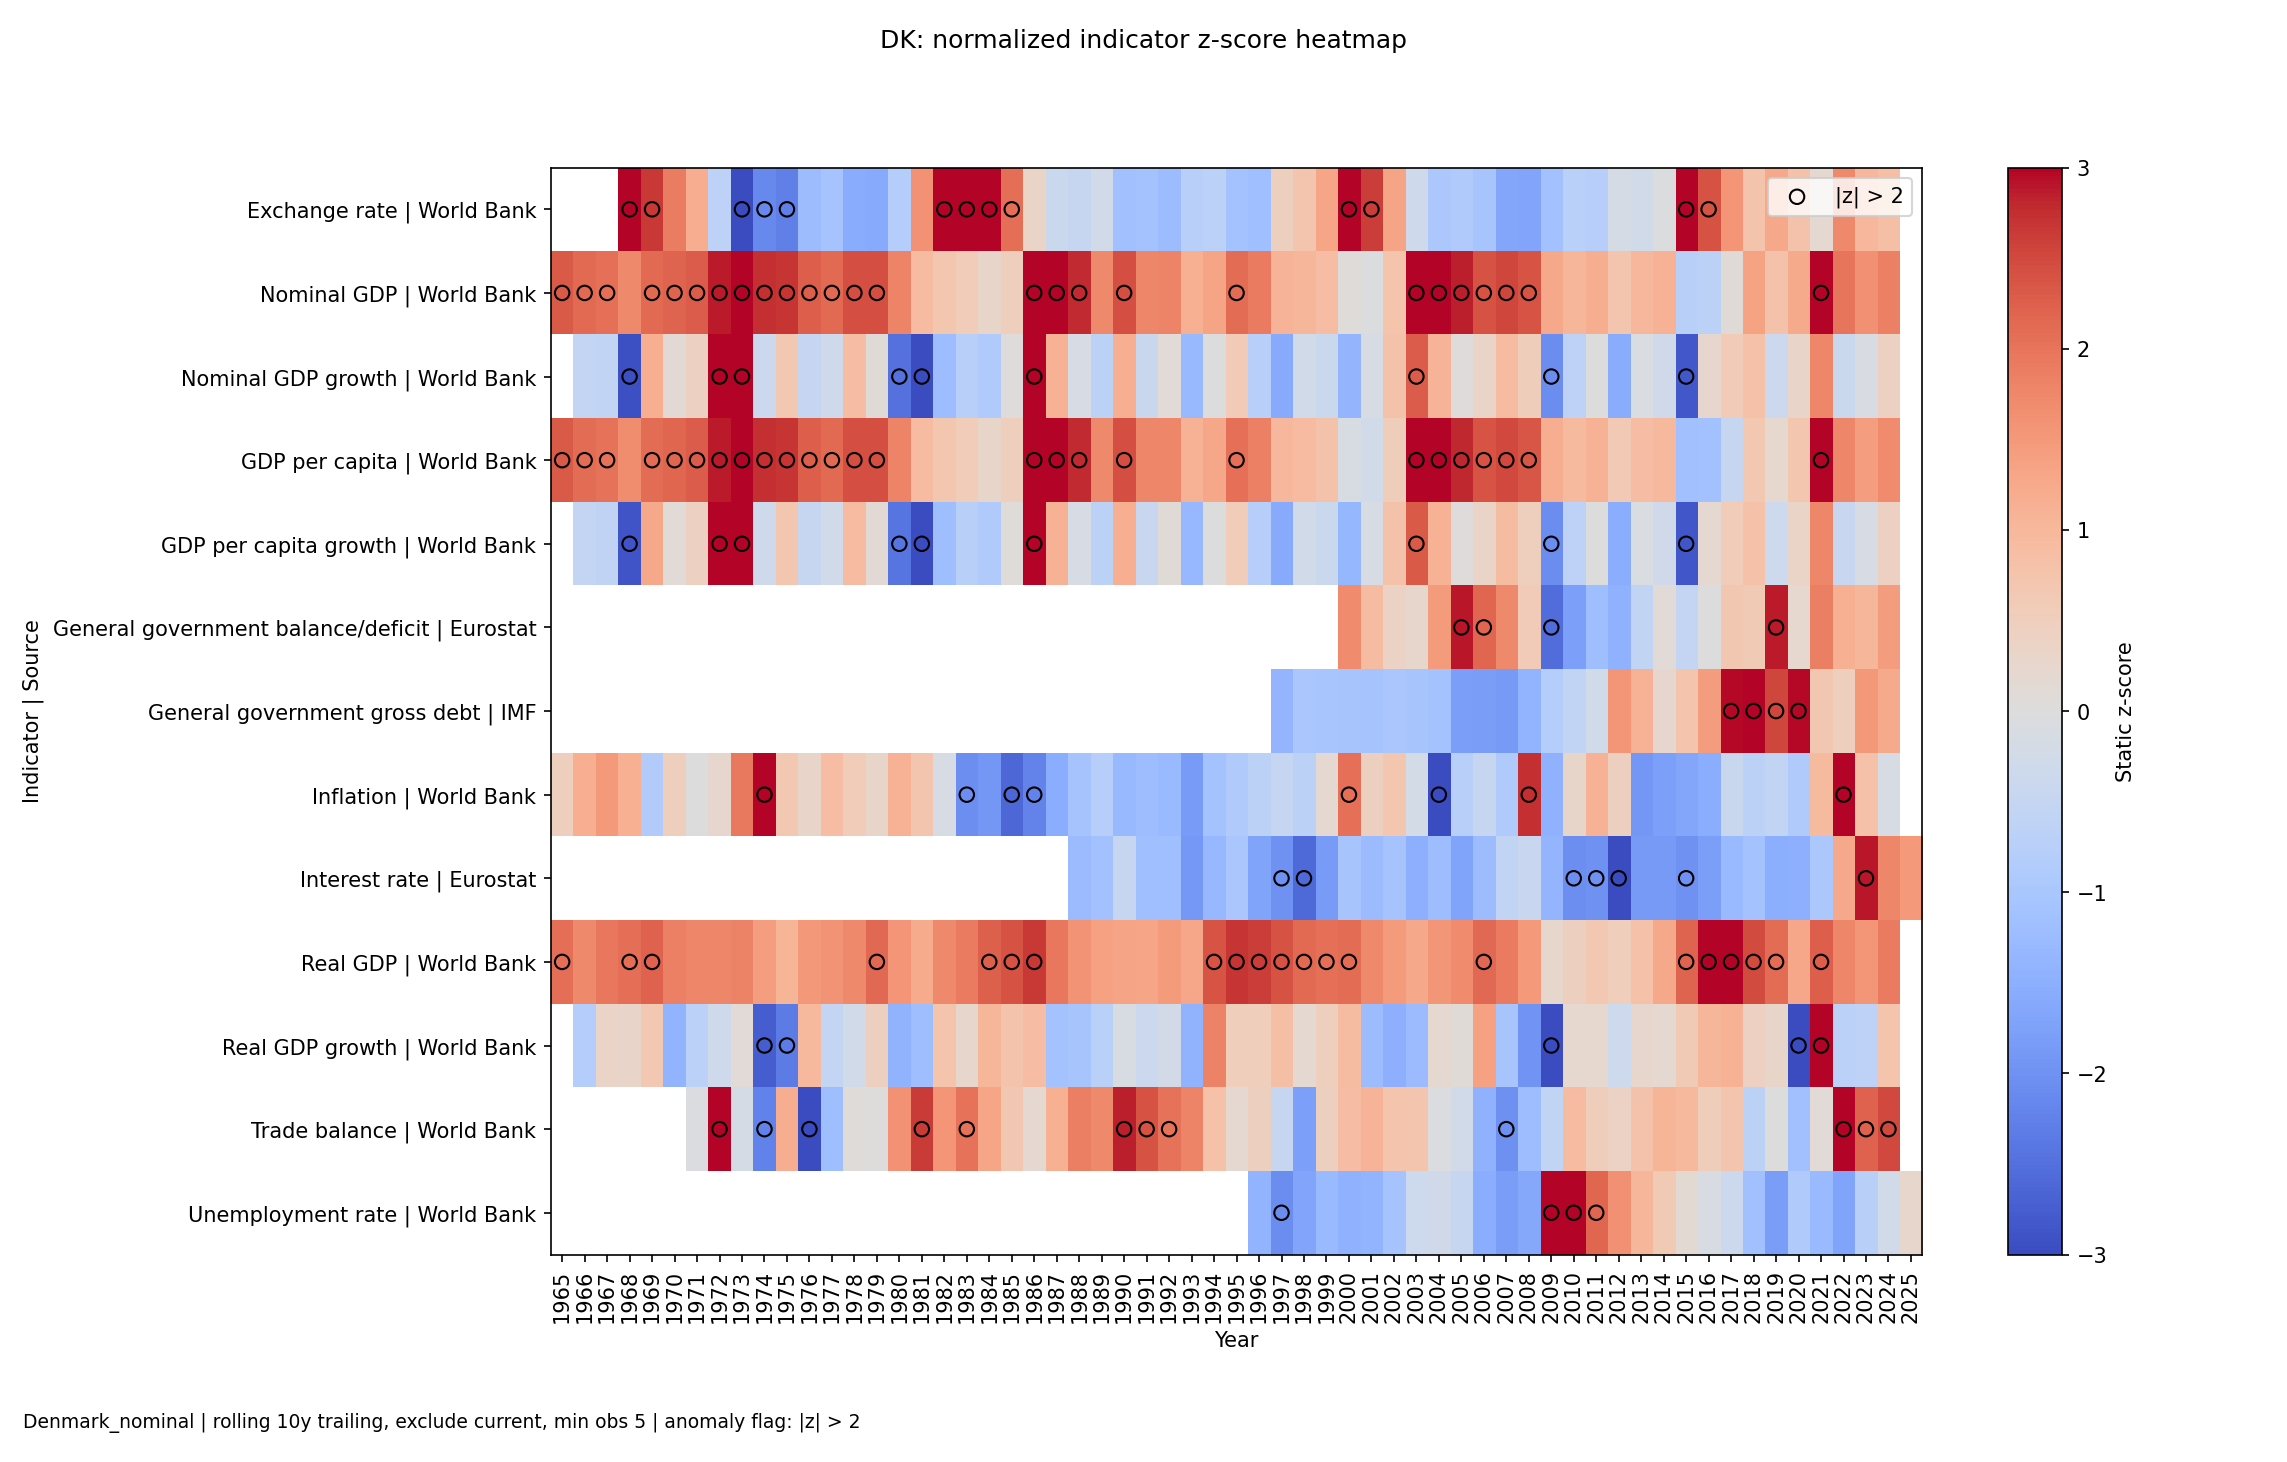

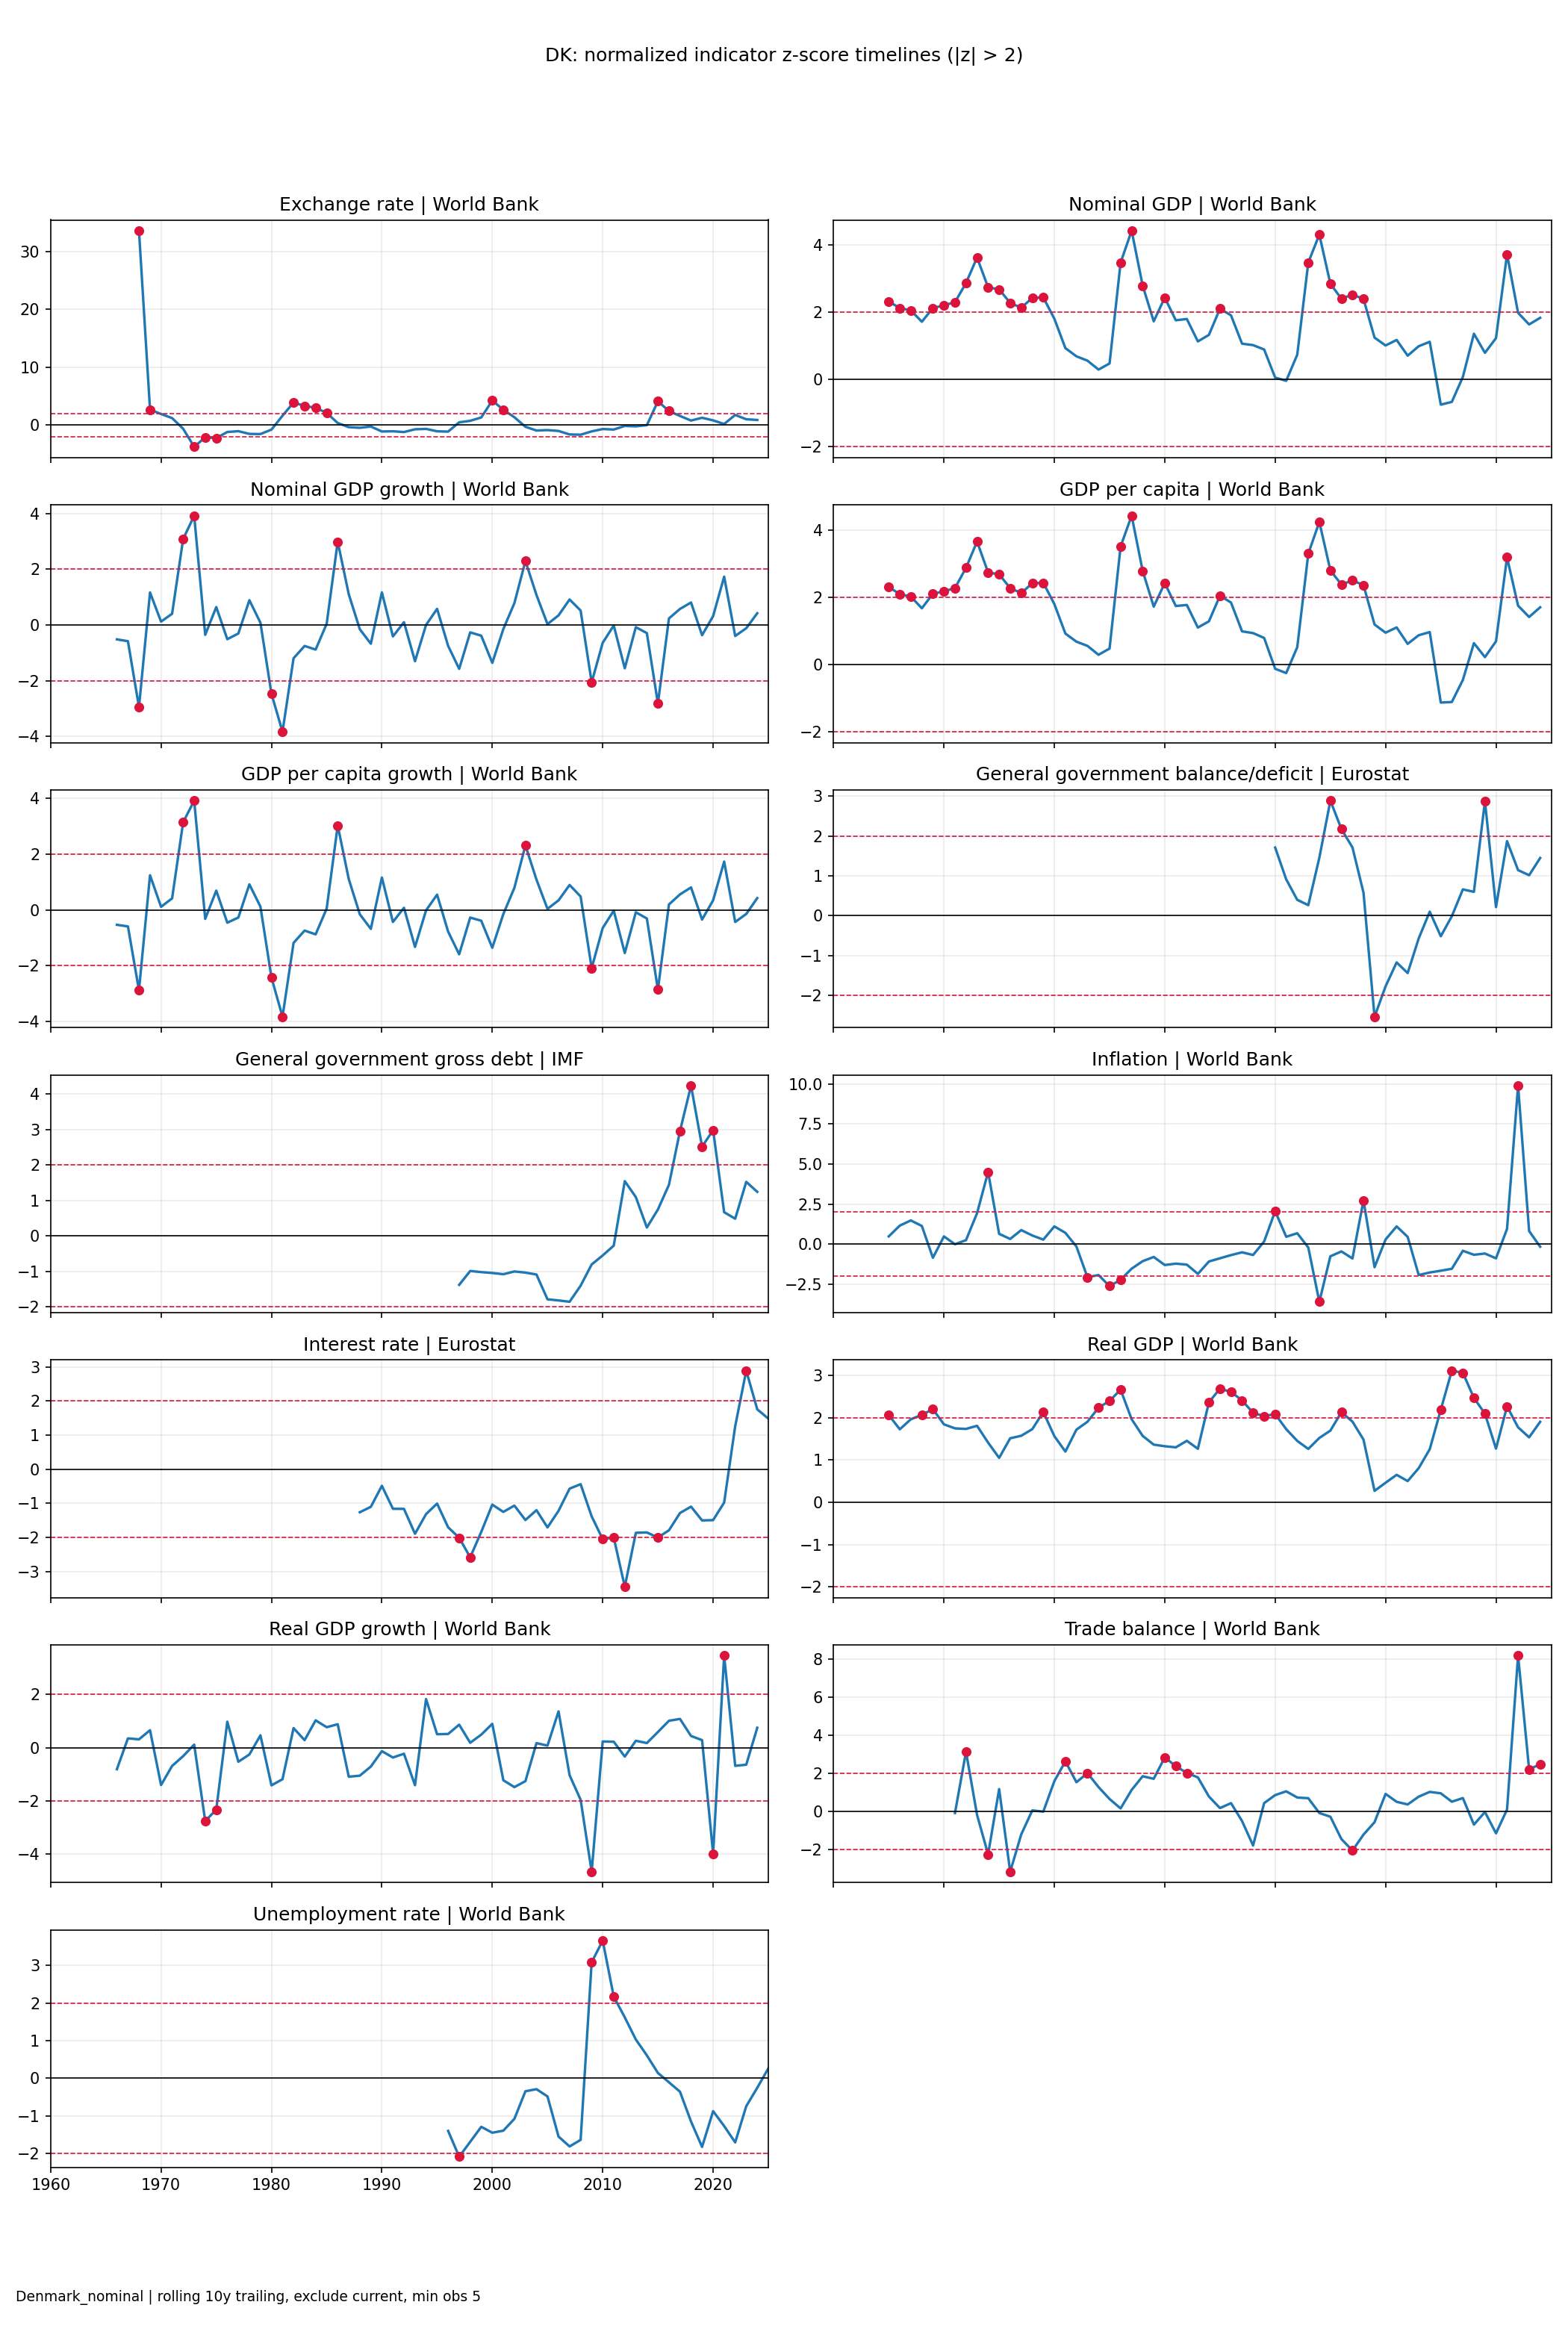

In [10]:
nominal_presentation_view_config = deepcopy(presentation_view_config)
nominal_presentation_view_config["view_name"] = "nominal_view"
nominal_presentation_view_config["region_label"] = "Denmark_nominal"
nominal_presentation_view_config["transformation_strategy"] = (
    _build_recommended_gdp_growth_transformation_strategy(include_nominal_gdp=True)
)

_dk_presentation_nominal_view = _render_denmark_rolling_section(
    view_name=nominal_presentation_view_config["view_name"],
    view_config=nominal_presentation_view_config,
)
